# AIC and BIC in ARIMA

## 1. What are AIC and BIC?

When building an **ARIMA model**, ACF and PACF help us generate candidate values of $p$, $d$, and $q$.

For example, we may have several candidate models:

$$
\text{ARIMA}(1,1,1)
$$

$$
\text{ARIMA}(2,1,1)
$$

$$
\text{ARIMA}(1,1,2)
$$

$$
\text{ARIMA}(2,1,2)
$$

The question is:

> **Which model should we choose?**

This is where **AIC** and **BIC** are useful.

Both are **model selection criteria** that balance:

1. **How well the model fits the data**
2. **How complex the model is**

The general idea is:

$$
\boxed{
\text{Good Model}
=================

\text{Good Fit}
+
\text{Low Complexity}
}
$$

A model that fits the training data extremely well is not necessarily the best model if it uses too many parameters.

---

# 2. Why Do We Need AIC and BIC?

Suppose we have two models:

### Model A

$$
\text{ARIMA}(1,1,1)
$$

### Model B

$$
\text{ARIMA}(5,1,5)
$$

Model B has many more parameters.

Because it is more flexible, it can usually fit the training data better.

However, there is a risk that Model B is simply learning the **noise** in the training data.

This is called:

$$
\boxed{\text{Overfitting}}
$$

AIC and BIC address this by adding a **penalty for model complexity**.

Therefore:

$$
\boxed{
\text{AIC/BIC}
==============

\text{Model Fit}
+
\text{Complexity Penalty}
}
$$

---

# 3. AIC

AIC stands for:

> **Akaike Information Criterion**

The formula is:

$$
\boxed{
AIC=-2\ln(L)+2k
}
$$

where:

* $L$ = maximum likelihood of the model
* $k$ = number of estimated parameters

---

## 3.1 Understanding the AIC Formula

AIC has two components:

$$
AIC=
\underbrace{-2\ln(L)}*{\text{Model Fit}}
+
\underbrace{2k}*{\text{Complexity Penalty}}
$$

### First Component: $-2\ln(L)$

This represents the model's fit to the observed data through its likelihood.

Higher likelihood means:

$$
L\uparrow
$$

Therefore:

$$
\ln(L)\uparrow
$$

and:

$$
-2\ln(L)\downarrow
$$

So:

> **Better model fit generally results in a lower AIC, all else equal.**

---

### Second Component: $2k$

This is the penalty for model complexity.

If the number of parameters increases:

$$
k\uparrow
$$

then:

$$
2k\uparrow
$$

Therefore:

> **More parameters → Larger complexity penalty → Higher AIC**

---

# 4. BIC

BIC stands for:

> **Bayesian Information Criterion**

The formula is:

$$
\boxed{
BIC=-2\ln(L)+k\ln(n)
}
$$

where:

* $L$ = maximum likelihood
* $k$ = number of estimated parameters
* $n$ = number of observations

---

## 4.1 Understanding the BIC Formula

BIC consists of:

$$
BIC=
\underbrace{-2\ln(L)}*{\text{Model Fit}}
+
\underbrace{k\ln(n)}*{\text{Complexity Penalty}}
$$

The first term is the same as AIC.

The important difference is the complexity penalty.

### AIC penalty

$$
2k
$$

### BIC penalty

$$
k\ln(n)
$$

Therefore:

$$
\boxed{
\text{BIC penalizes complexity more strongly than AIC when } n>e^2\approx7.39
}
$$

For most practical time-series datasets, $n$ is much larger than this.

Thus, BIC generally tends to favor simpler models more strongly than AIC.

---

# 5. AIC vs BIC — Simple Example

Suppose we have two models.

|                              | Model A | Model B |
| ---------------------------- | ------: | ------: |
| Log Likelihood               |    -100 |     -95 |
| Number of parameters ($k$)   |       3 |       6 |
| Number of observations ($n$) |     100 |     100 |

Model B has a better likelihood because:

$$
-95>-100
$$

Therefore, Model B fits the observed data better according to likelihood.

However, Model B has twice as many parameters.

---

## 5.1 Calculate AIC

### Model A

$$
AIC=-2(-100)+2(3)
$$

$$
AIC=200+6
$$

$$
\boxed{AIC_A=206}
$$

### Model B

$$
AIC=-2(-95)+2(6)
$$

$$
AIC=190+12
$$

$$
\boxed{AIC_B=202}
$$

Therefore:

$$
202<206
$$

So AIC chooses:

$$
\boxed{\text{Model B}}
$$

Even though Model B is more complex, its improvement in likelihood is large enough to compensate for the additional AIC penalty.

---

# 6. Calculate BIC

For:

$$
n=100
$$

we have:

$$
\ln(100)\approx4.605
$$

### Model A

$$
BIC=200+3\ln(100)
$$

$$
BIC=200+3(4.605)
$$

$$
\boxed{
BIC_A\approx213.815
}
$$

### Model B

$$
BIC=190+6\ln(100)
$$

$$
BIC=190+6(4.605)
$$

$$
\boxed{
BIC_B\approx217.630
}
$$

Therefore:

$$
213.815<217.630
$$

So BIC chooses:

$$
\boxed{\text{Model A}}
$$

---

# 7. Why Did AIC and BIC Choose Different Models?

This happens because BIC applies a stronger complexity penalty for sufficiently large sample sizes.

In this example:

### AIC

AIC says:

> The improvement in model fit is worth the additional complexity.

### BIC

BIC says:

> The improvement in model fit is not enough to justify the additional complexity.

Therefore:

$$
\boxed{
\text{AIC tends to allow more complex models}
}
$$

while:

$$
\boxed{
\text{BIC tends to prefer simpler models}
}
$$

These are tendencies, not absolute rules.

---

# 8. Important Rule: Lower Is Better

For both AIC and BIC:

$$
\boxed{
\text{Lower value = Better model}
}
$$

For example:

| Model        | AIC |
| ------------ | --: |
| ARIMA(1,1,1) | 520 |
| ARIMA(2,1,1) | 508 |
| ARIMA(2,1,2) | 515 |

The preferred model according to AIC is:

$$
\boxed{
\text{ARIMA}(2,1,1)
}
$$

because:

$$
508<515<520
$$

Similarly, for BIC:

| Model        | BIC |
| ------------ | --: |
| ARIMA(1,1,1) | 530 |
| ARIMA(2,1,1) | 525 |
| ARIMA(2,1,2) | 529 |

The preferred model according to BIC is:

$$
\boxed{
\text{ARIMA}(2,1,1)
}
$$

because it has the lowest BIC.

---

# 9. AIC and BIC in ARIMA

Suppose ACF and PACF suggest that we should try several models:

$$
\text{ARIMA}(1,1,1)
$$

$$
\text{ARIMA}(1,1,2)
$$

$$
\text{ARIMA}(2,1,1)
$$

$$
\text{ARIMA}(2,1,2)
$$

We can fit all of them and compare their AIC and BIC values.

For example:

| Model        |   AIC |   BIC |
| ------------ | ----: | ----: |
| ARIMA(1,1,1) | 510.2 | 518.7 |
| ARIMA(1,1,2) | 508.6 | 519.9 |
| ARIMA(2,1,1) | 507.9 | 519.2 |
| ARIMA(2,1,2) | 507.5 | 521.6 |

### AIC

Lowest AIC:

$$
507.5
$$

Therefore, AIC chooses:

$$
\boxed{
\text{ARIMA}(2,1,2)
}
$$

### BIC

Lowest BIC:

$$
518.7
$$

Therefore, BIC chooses:

$$
\boxed{
\text{ARIMA}(1,1,1)
}
$$

This demonstrates that:

$$
\boxed{
\text{AIC and BIC can choose different models}
}
$$

---

# 10. AIC and BIC in Python

We can compare multiple ARIMA models using `statsmodels`.

```python
from statsmodels.tsa.arima.model import ARIMA

models = [
    (1, 1, 1),
    (1, 1, 2),
    (2, 1, 1),
    (2, 1, 2)
]

results = []

for order in models:

    model = ARIMA(
        series_3,
        order=order
    )

    result = model.fit()

    results.append({
        "Model": order,
        "AIC": result.aic,
        "BIC": result.bic
    })

for result in results:
    print(
        result["Model"],
        "AIC:", result["AIC"],
        "BIC:", result["BIC"]
    )
```

Example output:

```text
(1, 1, 1) AIC: 510.2 BIC: 518.7
(1, 1, 2) AIC: 508.6 BIC: 519.9
(2, 1, 1) AIC: 507.9 BIC: 519.2
(2, 1, 2) AIC: 507.5 BIC: 521.6
```

We can then identify the model with the lowest AIC and the model with the lowest BIC.

---

# 11. Automatically Finding the Lowest AIC/BIC

We can convert the results into a DataFrame:

```python
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

models = [
    (1, 1, 1),
    (1, 1, 2),
    (2, 1, 1),
    (2, 1, 2)
]

results = []

for order in models:

    model = ARIMA(
        series_3,
        order=order
    )

    result = model.fit()

    results.append({
        "Model": order,
        "AIC": result.aic,
        "BIC": result.bic
    })

results_df = pd.DataFrame(results)

print(results_df)
```

Find the model with the lowest AIC:

```python
best_aic_model = results_df.loc[
    results_df["AIC"].idxmin()
]

print("Best AIC model:")
print(best_aic_model)
```

Find the model with the lowest BIC:

```python
best_bic_model = results_df.loc[
    results_df["BIC"].idxmin()
]

print("Best BIC model:")
print(best_bic_model)
```

---

# 12. Why Not Just Choose the Model with the Lowest Training Error?

Suppose we keep adding AR and MA terms:

$$
\text{ARIMA}(1,1,1)
$$

$$
\text{ARIMA}(2,1,2)
$$

$$
\text{ARIMA}(5,1,5)
$$

$$
\text{ARIMA}(10,1,10)
$$

A more complicated model generally has more flexibility and can fit the training data better.

However, it may start learning random fluctuations:

$$
\boxed{\text{Noise}}
$$

instead of the underlying time-series pattern.

This causes:

$$
\boxed{\text{Overfitting}}
$$

AIC and BIC discourage blindly adding parameters by penalizing model complexity.

---

# 13. AIC vs BIC

| Feature              | AIC                          | BIC                                    |
| -------------------- | ---------------------------- | -------------------------------------- |
| Full name            | Akaike Information Criterion | Bayesian Information Criterion         |
| Formula              | $-2\ln(L)+2k$                | $-2\ln(L)+k\ln(n)$                     |
| Uses likelihood      | Yes                          | Yes                                    |
| Penalizes complexity | Yes                          | Yes                                    |
| Complexity penalty   | $2k$                         | $k\ln(n)$                              |
| Penalty strength     | Generally lower              | Generally higher for typical large $n$ |
| Typical tendency     | More flexible models         | Simpler models                         |
| Lower is better      | Yes                          | Yes                                    |

---

# 14. AIC vs BIC — Intuition

Think of choosing between two models.

### Model A

Simple model:

* Fewer parameters
* Lower complexity
* Good performance

### Model B

Complex model:

* More parameters
* Higher complexity
* Slightly better fit

AIC asks:

> Is the improvement in fit worth the additional complexity?

BIC is generally more conservative:

> Is the improvement in fit large enough to justify the additional complexity?

Therefore:

$$
\boxed{
\text{BIC generally favors simpler models more strongly}
}
$$

---

# 15. AICc

There is also a corrected version of AIC called **AICc**.

AICc is:

$$
\boxed{
AICc
====

AIC+
\frac{2k(k+1)}{n-k-1}
}
$$

It is particularly useful when the sample size is relatively small compared with the number of parameters.

As $n$ becomes large:

$$
\boxed{
AICc\approx AIC
}
$$

Therefore:

* **Large sample** → AIC and AICc become similar
* **Small sample** → AICc applies a stronger finite-sample correction

---

# 16. AIC/BIC Do Not Directly Measure Forecast Accuracy

This is extremely important.

AIC and BIC are primarily **model selection criteria**.

They do not directly answer:

> "Which model will produce the most accurate future forecasts?"

For forecasting, we should also evaluate the model on **unseen data**.

Common metrics include:

## MAE

$$
\boxed{
MAE=
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\hat{y}_i|
}
$$

---

## MSE

$$
\boxed{
MSE=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
$$

---

## RMSE

$$
\boxed{
RMSE=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
}
$$

---

## MAPE

$$
\boxed{
MAPE=
\frac{100}{n}
\sum_{i=1}^{n}
\left|
\frac{y_i-\hat{y}_i}{y_i}
\right|
}
$$

> **Note:** MAPE can be problematic when actual values are zero or close to zero.

---

# 17. AIC/BIC vs RMSE

These concepts should not be confused.

### AIC/BIC

Evaluate:

$$
\boxed{
\text{Model Fit}+\text{Model Complexity}
}
$$

### RMSE/MAE

Evaluate:

$$
\boxed{
\text{Forecast Error}
}
$$

For example:

| Model        | AIC | BIC | Test RMSE |
| ------------ | --: | --: | --------: |
| ARIMA(1,1,1) | 510 | 519 |      15.2 |
| ARIMA(2,1,1) | 508 | 519 |      12.8 |
| ARIMA(2,1,2) | 507 | 522 |      13.4 |

AIC chooses:

$$
\text{ARIMA}(2,1,2)
$$

because it has the lowest AIC.

However, the lowest test RMSE belongs to:

$$
\text{ARIMA}(2,1,1)
$$

Therefore:

> **For actual forecasting, out-of-sample validation is extremely important.**

---

# 18. Residual Diagnostics

After selecting an ARIMA model, we should also examine its residuals.

The residual is:

$$
\boxed{
e_t=Y_t-\hat{Y}_t
}
$$

Ideally, residuals should behave approximately like **white noise**.

We want:

### Mean

$$
E(e_t)\approx0
$$

### Constant Variance

Residual variance should remain approximately constant.

### No Autocorrelation

The residual ACF should not contain statistically significant autocorrelation.

If the residuals still contain strong autocorrelation, the ARIMA model may not have captured all the structure in the time series.

---

# 19. Residual ACF in Python

```python
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(
    result.resid.dropna(),
    lags=20
)

plt.show()
```

If the residual ACF contains significant spikes, the model may not have captured all the time-series structure.

---

# 20. Ljung-Box Test

The **Ljung-Box test** can be used to check whether residuals contain significant autocorrelation.

```python
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_result = acorr_ljungbox(
    result.resid.dropna(),
    lags=[10],
    return_df=True
)

print(ljung_box_result)
```

The hypotheses are:

$$
H_0:
\text{Residuals are not autocorrelated}
$$

$$
H_1:
\text{Residuals are autocorrelated}
$$

If the p-value is sufficiently large, we fail to reject $H_0$.

This provides evidence that there is no significant autocorrelation up to the tested lag.

> A Ljung-Box test does not prove that the residuals are perfectly white noise. It is one part of residual diagnostics.

---

# 21. Complete ARIMA Model Selection Workflow

The complete process can be summarized as:

```text
Original Time Series
        │
        ▼
   Plot the Series
        │
        ▼
 Check Stationarity
        │
        ▼
     ADF Test
        │
        ├────────────────┐
        │                │
Non-Stationary       Stationary
        │                │
        ▼                │
  Differencing           │
        │                │
        ▼                │
    Determine d           │
        │                │
        └───────┬────────┘
                ▼
       Stationary Series
                │
                ▼
           ACF / PACF
             │     │
             ▼     ▼
             q     p
             │     │
             └──┬──┘
                ▼
       Candidate ARIMA Models
                │
                ▼
           Calculate AIC/BIC
                │
                ▼
       Select Candidate Models
                │
                ▼
        Check Residuals
                │
                ▼
      Validate on Test Data
                │
                ▼
             Forecast
```

---

# 22. Connection Between All Concepts

The entire ARIMA process can be remembered as:

$$
\boxed{
ADF\rightarrow d
}
$$

$$
\boxed{
PACF\rightarrow p
}
$$

$$
\boxed{
ACF\rightarrow q
}
$$

$$
\boxed{
AIC/BIC
\rightarrow
\text{Compare Candidate Models}
}
$$

$$
\boxed{
\text{Residual Diagnostics}
\rightarrow
\text{Check Model Adequacy}
}
$$

$$
\boxed{
RMSE/MAE
\rightarrow
\text{Evaluate Forecast Performance}
}
$$

---

# 23. Important Practical Points

### 1. Do not automatically choose $d=1$

Use stationarity tests, visual analysis, and domain knowledge.

---

### 2. ACF/PACF are identification tools, not absolute rules

The common interpretation is:

$$
\text{PACF}\rightarrow p
$$

and:

$$
\text{ACF}\rightarrow q
$$

However, real-world ARIMA identification can be more complicated.

---

### 3. Lowest AIC does not always mean best forecast

AIC and BIC are primarily **in-sample model-selection criteria**.

Future forecasting performance should be evaluated using **out-of-sample validation**.

---

### 4. Residuals should resemble white noise

After fitting the model, there should ideally be no meaningful structure left in the residuals.

---

### 5. Avoid over-differencing

Too much differencing can introduce unnecessary complexity and may make the model harder to estimate.

---

### 6. Preserve temporal order

When evaluating forecasts, do not randomly shuffle time-series observations.

Use:

```text
Past   → Training
Future → Testing
```

---

# 24. Final Summary

| Tool             | Main Purpose                                      |
| ---------------- | ------------------------------------------------- |
| **ADF Test**     | Check whether the series is stationary            |
| **Differencing** | Make a non-stationary series stationary           |
| **$d$**          | Number of differences required                    |
| **PACF**         | Helps identify candidate AR order $p$             |
| **ACF**          | Helps identify candidate MA order $q$             |
| **AIC**          | Compare models using fit and complexity           |
| **BIC**          | Compare models with a stronger complexity penalty |
| **AICc**         | AIC correction for smaller samples                |
| **Residual ACF** | Check whether residual autocorrelation remains    |
| **Ljung-Box**    | Test residual autocorrelation                     |
| **MAE/RMSE**     | Evaluate forecasting accuracy on unseen data      |

---

# 25. Most Important Formulas

### AIC

$$
\boxed{
AIC=-2\ln(L)+2k
}
$$

### BIC

$$
\boxed{
BIC=-2\ln(L)+k\ln(n)
}
$$

### AICc

$$
\boxed{
AICc
====

AIC+
\frac{2k(k+1)}{n-k-1}
}
$$

### MAE

$$
\boxed{
MAE=
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\hat{y}_i|
}
$$

### RMSE

$$
\boxed{
RMSE=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
}
$$

---

# 26. Easy Way to Remember

> **ADF → $d$**
> **PACF → $p$**
> **ACF → $q$**
> **AIC/BIC → Compare candidate models**
> **Residuals → Check model adequacy**
> **MAE/RMSE → Check forecasting performance**

### One-line intuition

> **AIC and BIC help us choose a model that achieves a good fit without unnecessarily increasing model complexity.**

The key distinction is:

$$
\boxed{
\text{AIC/BIC}
\rightarrow
\text{Model Selection}
}
$$

while:

$$
\boxed{
\text{MAE/RMSE}
\rightarrow
\text{Forecast Evaluation}
}
$$

And finally:

$$
\boxed{
\text{Best ARIMA model}
\neq
\text{necessarily the model with the lowest AIC}
}
$$

A strong forecasting model should have:

$$
\boxed{
\text{Good AIC/BIC}
+
\text{White-Noise Residuals}
+
\text{Good Out-of-Sample Performance}
}
$$


In [73]:
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [74]:
series = pd.read_csv('monthly-beer-production-in-austr.csv',header=0, index_col=0 )

In [75]:
series.head()

,Monthly beer production
Month,
1956-01,93.2
1956-02,96.0
1956-03,95.2
1956-04,77.1
1956-05,70.9


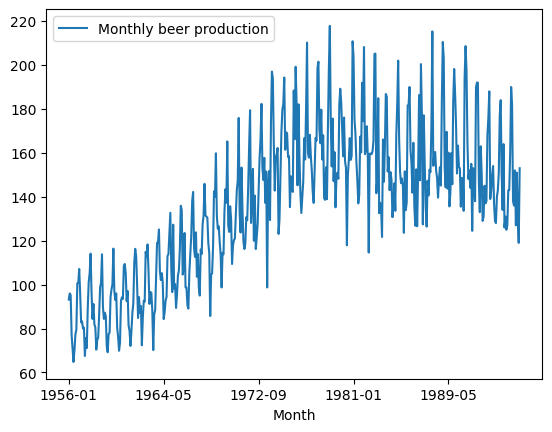

In [76]:
series.plot()
plt.show()

In [77]:
X=series.values
result=adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.282661
p-value: 0.177621
Critical Values:
	1%: -3.445
	5%: -2.868
	10%: -2.570


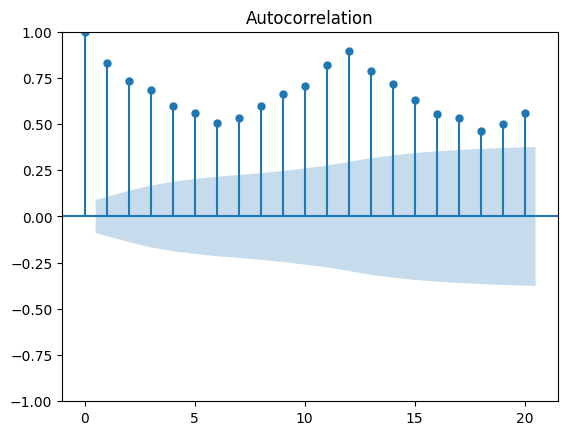

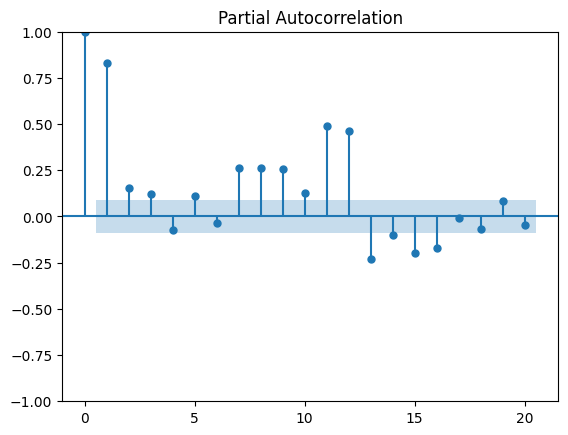

In [78]:
plot_acf(series, lags=20)
plot_pacf(series, lags=20)
plt.show()

In [79]:
from itertools import product

# First-order differencing
series_diff = series['Monthly beer production'].diff()

# Define p and q values
p_values = range(1, 3)
q_values = range(1, 3)

# Dictionary to store fitted models and their scores
fitted_model_dict = {}

# Try all combinations of p and q
for p, q in product(p_values, q_values):

    # Create ARIMA(p, 0, q) model
    arima_model = ARIMA(series_diff, order=(p, 0, q))

    # Fit the model
    arima_model_fit = arima_model.fit()

    # Store AIC and BIC scores
    aic_score = arima_model_fit.aic
    bic_score = arima_model_fit.bic

    fitted_model_dict[(p, q)] = {
        'AIC': aic_score,
        'BIC': bic_score
    }

d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\anaconda\Lib\site-packages\stats

In [80]:
for (p, q), scores in fitted_model_dict.items():
    print(f"ARIMA({p}, 0, {q}) - AIC: {scores['AIC']:.2f}, BIC: {scores['BIC']:.2f}")

ARIMA(1, 0, 1) - AIC: 4063.12, BIC: 4079.79
ARIMA(1, 0, 2) - AIC: 4064.39, BIC: 4085.22
ARIMA(2, 0, 1) - AIC: 4136.08, BIC: 4156.91
ARIMA(2, 0, 2) - AIC: 4057.45, BIC: 4082.44


In [81]:
train=series_diff[:400]
test=series_diff[400:]

In [96]:
model = ARIMA(train, order=(2, 0, 2))
model_fit = model.fit()

d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-inve

In [97]:
print(model_fit.summary())

                                  SARIMAX Results                                  
Dep. Variable:     Monthly beer production   No. Observations:                  400
Model:                      ARIMA(2, 0, 2)   Log Likelihood               -1692.264
Date:                     Tue, 11 Aug 2026   AIC                           3396.528
Time:                             17:36:24   BIC                           3420.477
Sample:                         01-01-1956   HQIC                          3406.012
                              - 04-01-1989                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2003      0.072      2.793      0.005       0.060       0.341
ar.L1         -0.3170      0.120     -2.648      0.008      -0.552      -0.082
ar.L2       

In [98]:
test.tail()

Month
1995-04-01   -25.0
1995-05-01    24.0
1995-06-01   -21.0
1995-07-01   -11.0
1995-08-01    34.0
Name: Monthly beer production, dtype: float64

In [99]:
pred_start_date = '1995-09'
pred_end_date = '2007-12'

In [100]:
forecast=model_fit.predict(start=pred_start_date, end=pred_end_date)

In [101]:
forecast

1995-09-01    0.200334
1995-10-01    0.200334
1995-11-01    0.200334
1995-12-01    0.200334
1996-01-01    0.200334
                ...   
2007-08-01    0.200334
2007-09-01    0.200334
2007-10-01    0.200334
2007-11-01    0.200334
2007-12-01    0.200334
Freq: MS, Name: predicted_mean, Length: 148, dtype: float64

In [102]:
test.index = pd.to_datetime(test.index)

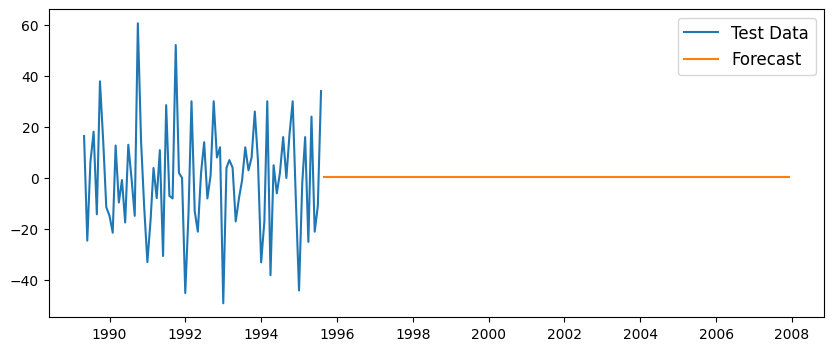

In [103]:
plt.figure(figsize=(10, 4))
plt.plot(test.index, test.values, label='Test Data')
plt.plot(forecast.index, forecast.values, label='Forecast')
plt.legend(fontsize=12)
plt.show()

In [104]:
def invert_diff(last_actual, differences):
    inverted_values = []
    
    last_observation = last_actual
    
    for diff in differences:
        inverted_value = last_observation + diff
        inverted_values.append(inverted_value)
        last_observation = inverted_value
    
    return inverted_values

In [105]:
forecast_og = invert_diff(
    series['Monthly beer production'].iloc[-1],
    forecast
)

forecast_og

[np.float64(153.20033397715588),
 np.float64(153.40066795509318),
 np.float64(153.6010019324498),
 np.float64(153.80133591023792),
 np.float64(154.0016698877054),
 np.float64(154.20200386541114),
 np.float64(154.40233784293983),
 np.float64(154.60267182060008),
 np.float64(154.80300579816256),
 np.float64(155.0033397757977),
 np.float64(155.20367375337887),
 np.float64(155.40400773100015),
 np.float64(155.60434170859162),
 np.float64(155.80467568620523),
 np.float64(156.00500966380238),
 np.float64(156.20534364141176),
 np.float64(156.40567761901207),
 np.float64(156.6060115966191),
 np.float64(156.80634557422115),
 np.float64(157.00667955182692),
 np.float64(157.2070135294299),
 np.float64(157.40734750703496),
 np.float64(157.60768148463848),
 np.float64(157.80801546224313),
 np.float64(158.00834943984694),
 np.float64(158.20868341745137),
 np.float64(158.40901739505534),
 np.float64(158.60935137265966),
 np.float64(158.80968535026372),
 np.float64(159.01001932786798),
 np.float64(159

In [106]:
index_future = pd.date_range(start='1995-09', end='2007-12', freq='MS')
index_future

DatetimeIndex(['1995-09-01', '1995-10-01', '1995-11-01', '1995-12-01',
               '1996-01-01', '1996-02-01', '1996-03-01', '1996-04-01',
               '1996-05-01', '1996-06-01',
               ...
               '2007-03-01', '2007-04-01', '2007-05-01', '2007-06-01',
               '2007-07-01', '2007-08-01', '2007-09-01', '2007-10-01',
               '2007-11-01', '2007-12-01'],
              dtype='datetime64[us]', length=148, freq='MS')

In [107]:
forecast_series = pd.Series(forecast_og, index=index_future)
forecast_series

1995-09-01    153.200334
1995-10-01    153.400668
1995-11-01    153.601002
1995-12-01    153.801336
1996-01-01    154.001670
                 ...    
2007-08-01    181.848093
2007-09-01    182.048427
2007-10-01    182.248761
2007-11-01    182.449095
2007-12-01    182.649429
Freq: MS, Length: 148, dtype: float64

In [108]:
series.index = pd.to_datetime(series.index)

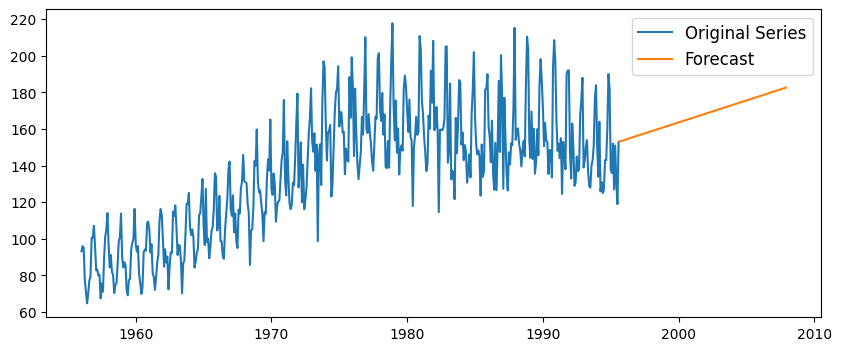

In [110]:
plt.figure(figsize=(10, 4))
plt.plot(series.index, series.values, label='Original Series')
plt.plot(forecast_series.index, forecast_series.values, label='Forecast')
plt.legend(fontsize=12)
plt.show()